In [1041]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVR, NuSVR
from sklearn.tree import  DecisionTreeRegressor

In [1042]:
dataset=pd.read_csv(r"C:\Users\rohit\Downloads\Housing (2).csv")

In [1043]:
dataset.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
330,3990000,4050,2,1,2,yes,yes,yes,no,no,0,yes,unfurnished
387,3500000,4240,3,1,2,yes,no,no,no,yes,0,no,semi-furnished
462,3080000,2160,3,1,2,no,no,yes,no,no,0,no,semi-furnished
468,3010000,2835,2,1,1,yes,no,no,no,no,0,no,semi-furnished
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
12,9310000,6550,4,2,2,yes,no,no,no,yes,1,yes,semi-furnished
525,2345000,3640,2,1,1,yes,no,no,no,no,0,no,unfurnished
476,2940000,5850,3,1,2,yes,no,yes,no,no,1,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
501,2660000,2430,3,1,1,no,no,no,no,no,0,no,unfurnished


In [1044]:
dataset.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [1045]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [1046]:
dataset.duplicated().sum()

np.int64(0)

In [1047]:
dataset[["price","area","bedrooms","bathrooms","stories"]].corr()

,price,area,bedrooms,bathrooms,stories
price,1.000000,0.535997,0.366494,0.517545,0.420712
area,0.535997,1.000000,0.151858,0.193820,0.083996
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165
stories,0.420712,0.083996,0.408564,0.326165,1.000000


In [1048]:
dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


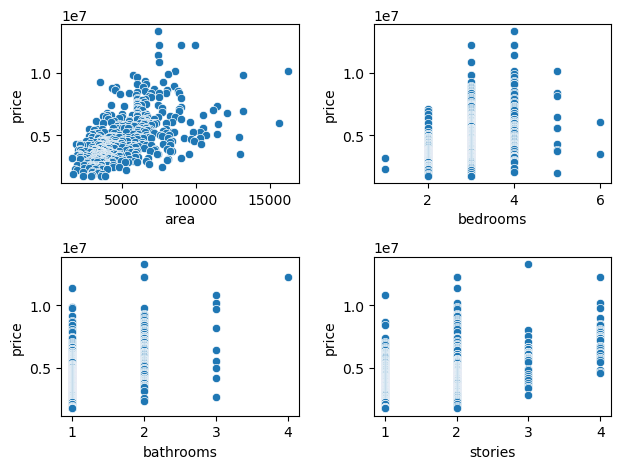

In [1049]:
plt.subplot(2,2,1)
sns.scatterplot(x=dataset["area"],y=dataset["price"])
plt.subplot(2,2,2)
sns.scatterplot(x=dataset["bedrooms"],y=dataset["price"])
plt.subplot(2,2,3)
sns.scatterplot(x=dataset["bathrooms"],y=dataset["price"])
plt.subplot(2,2,4)
sns.scatterplot(x=dataset["stories"],y=dataset["price"])
plt.tight_layout()
plt.show()

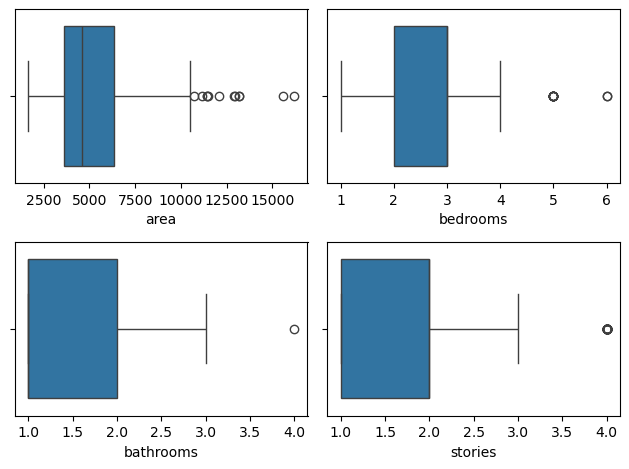

In [1050]:
plt.subplot(2,2,1)
sns.boxplot(x=dataset["area"])
plt.subplot(2,2,2)
sns.boxplot(x=dataset["bedrooms"])
plt.subplot(2,2,3)
sns.boxplot(x=dataset["bathrooms"])
plt.subplot(2,2,4)
sns.boxplot(x=dataset["stories"])
plt.tight_layout()
plt.show()

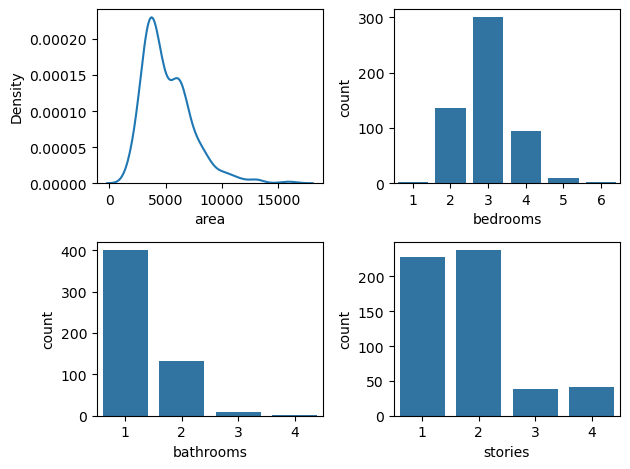

In [1051]:
plt.subplot(2,2,1)
sns.kdeplot(x=dataset["area"])
plt.subplot(2,2,2)
sns.countplot(x=dataset["bedrooms"])
plt.subplot(2,2,3)
sns.countplot(x=dataset["bathrooms"])
plt.subplot(2,2,4)
sns.countplot(x=dataset["stories"])
plt.tight_layout()
plt.show()

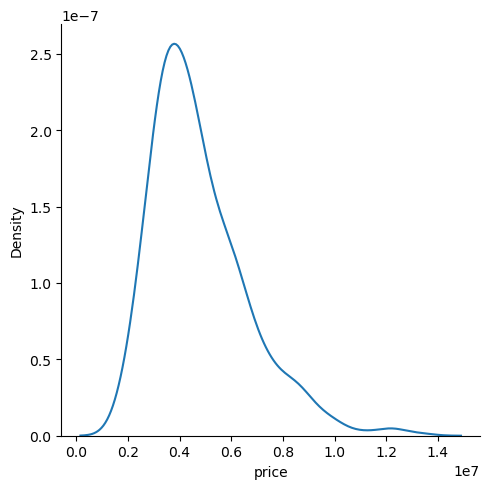

In [1052]:
sns.displot(dataset["price"],kind="kde")

In [1053]:
y=dataset["price"]
X=dataset.drop("price",axis=1)

In [1054]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [1055]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,yes,no,no,no,yes,1,no,furnished
93,7200,3,2,1,yes,no,yes,no,yes,3,no,semi-furnished
335,3816,2,1,1,yes,no,yes,no,yes,2,no,furnished
412,2610,3,1,2,yes,no,yes,no,no,0,yes,unfurnished
471,3750,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [1056]:
print("The training set size is: ",X_train.shape[0])
print("The test set size is: ",X_test.shape[0])

The training set size is:  436
The test set size is:  109


In [1057]:
encoder=OneHotEncoder()
encoder.fit(X_train[["mainroad","guestroom","basement","hotwaterheating","airconditioning", "prefarea","furnishingstatus"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

In [1058]:
object_transformed_train=np.int64(encoder.transform(X_train[["mainroad","guestroom","basement","hotwaterheating","airconditioning", "prefarea","furnishingstatus" ]]).toarray())
object_transformed_test=np.int64(encoder.transform(X_test[["mainroad","guestroom","basement","hotwaterheating","airconditioning", "prefarea","furnishingstatus"]]).toarray())

In [1059]:
X_train_encoded=X_train.drop(["mainroad","guestroom","basement","hotwaterheating","airconditioning", "prefarea","furnishingstatus"], axis=1)
X_test_encoded=X_test.drop(["mainroad","guestroom","basement","hotwaterheating","airconditioning", "prefarea","furnishingstatus"], axis=1)

In [1060]:
X_train_encoded.head()

,area,bedrooms,bathrooms,stories,parking
46,6000,3,2,4,1
93,7200,3,2,1,3
335,3816,2,1,1,2
412,2610,3,1,2,0
471,3750,3,1,2,0


In [1061]:
X_train_encoded[encoder.get_feature_names_out()]=object_transformed_train
X_test_encoded[encoder.get_feature_names_out()]=object_transformed_test

In [1062]:
X_train_encoded.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,0,1,1,0,1,0,1,0,0,1,1,0,1,0,0
93,7200,3,2,1,3,0,1,1,0,0,1,1,0,0,1,1,0,0,1,0
335,3816,2,1,1,2,0,1,1,0,0,1,1,0,0,1,1,0,1,0,0
412,2610,3,1,2,0,0,1,1,0,0,1,1,0,1,0,0,1,0,0,1
471,3750,3,1,2,0,0,1,1,0,1,0,1,0,1,0,1,0,0,0,1


In [1063]:
lr_model=LinearRegression()
lr_model.fit(X_train_encoded,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1064]:
X_test_encoded.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,1,1,0,1,0,0,1,1,0,1,0,1,0,0,0,1
77,6500,3,2,3,0,0,1,1,0,1,0,1,0,0,1,0,1,1,0,0
360,4040,2,1,1,0,0,1,1,0,1,0,1,0,1,0,1,0,0,1,0
90,5000,3,1,2,0,0,1,1,0,1,0,1,0,0,1,1,0,0,1,0
493,3960,3,1,1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0


In [1065]:

y_pred=lr_model.predict(X_test_encoded)

print("----------Performance report------------")
print("R2_score: ",r2_score(y_test,y_pred))
print("Root_mean_sqaured error: ", root_mean_squared_error(y_test,y_pred))
print("mean_sqaured error: ", mean_squared_error(y_test,y_pred))


----------Performance report------------
R2_score:  0.6529242642153188
Root_mean_sqaured error:  1324506.960091438
mean_sqaured error:  1754318687330.6616


In [1066]:
dataset.shape[0]

545